In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
print("Shape:", df.shape)
df.info()

Shape: (1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLev

In [3]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [4]:
print(df.isnull().sum().sum(), "missing values total")

0 missing values total


Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12 %


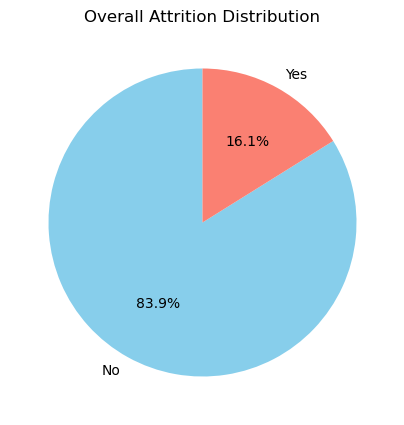

In [5]:
attrition_counts = df['Attrition'].value_counts()
print(attrition_counts)
print("\nAttrition Rate:", round(attrition_counts['Yes'] / len(df) * 100, 2), "%")

plt.figure(figsize=(5,5))
plt.pie(attrition_counts, labels=attrition_counts.index, autopct='%1.1f%%',
        colors=['skyblue', 'salmon'], startangle=90)
plt.title('Overall Attrition Distribution')
plt.show()

In [6]:
useless_cols = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df = df.drop(columns=[c for c in useless_cols if c in df.columns])
print("Remaining columns:", df.shape[1])

Remaining columns: 31


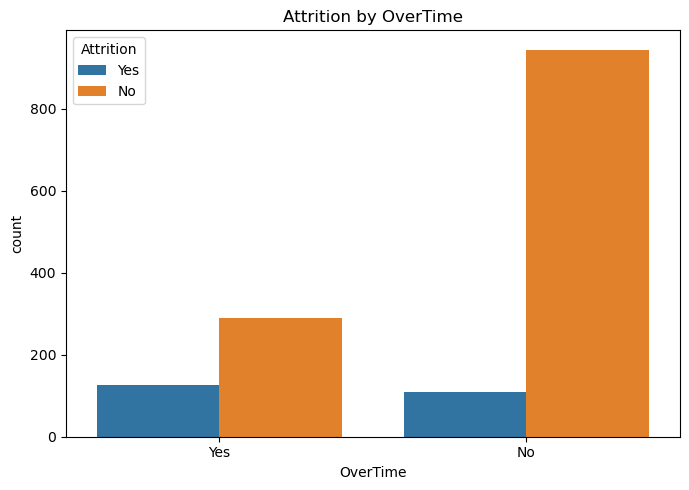

In [7]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='OverTime', hue='Attrition')
plt.title('Attrition by OverTime')
plt.tight_layout()
plt.show()

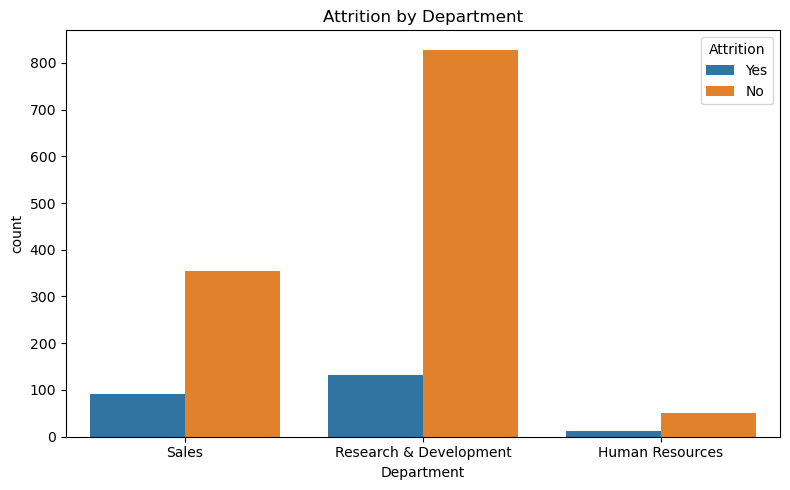

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Department', hue='Attrition')
plt.title('Attrition by Department')
plt.tight_layout()
plt.show()

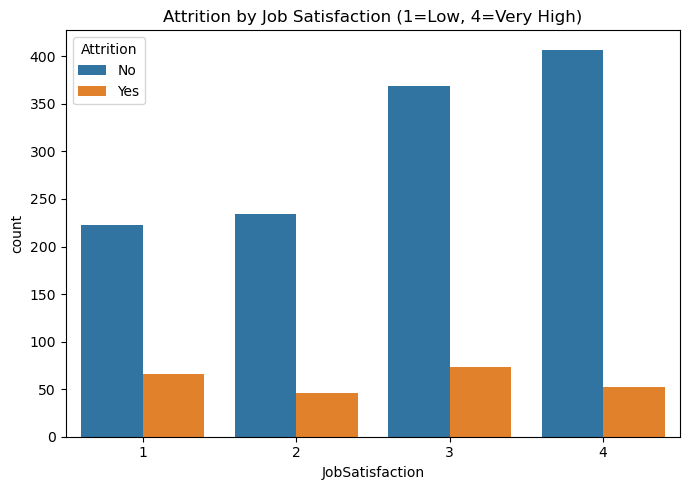

In [9]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='JobSatisfaction', hue='Attrition')
plt.title('Attrition by Job Satisfaction (1=Low, 4=Very High)')
plt.tight_layout()
plt.show()

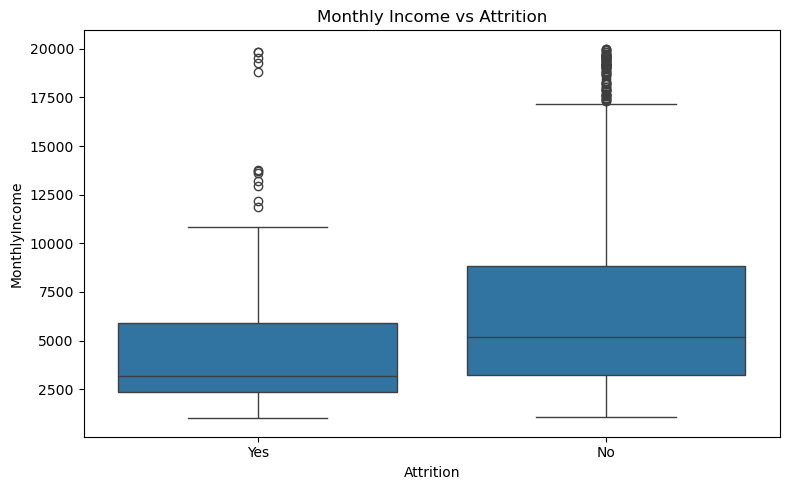

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome')
plt.title('Monthly Income vs Attrition')
plt.tight_layout()
plt.show()

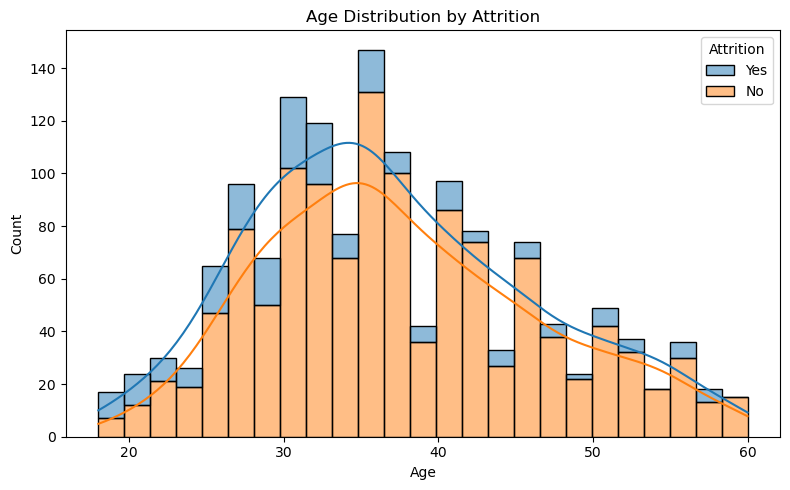

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Age', hue='Attrition', bins=25, kde=True, multiple='stack')
plt.title('Age Distribution by Attrition')
plt.tight_layout()
plt.show()

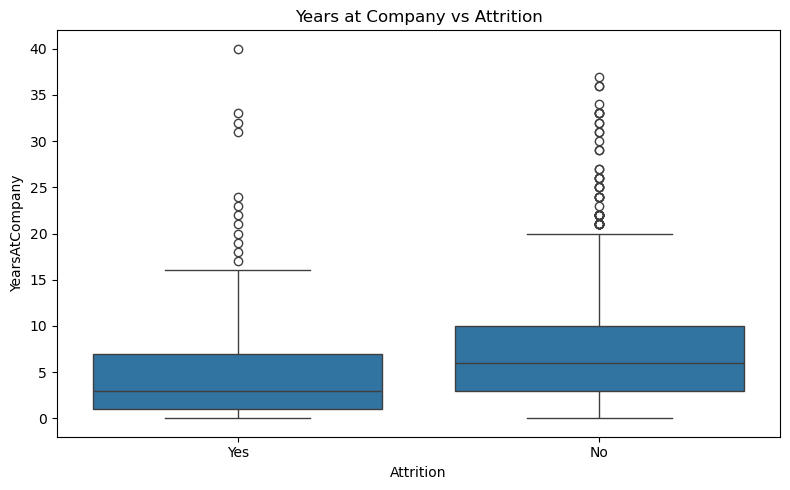

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Attrition', y='YearsAtCompany')
plt.title('Years at Company vs Attrition')
plt.tight_layout()
plt.show()

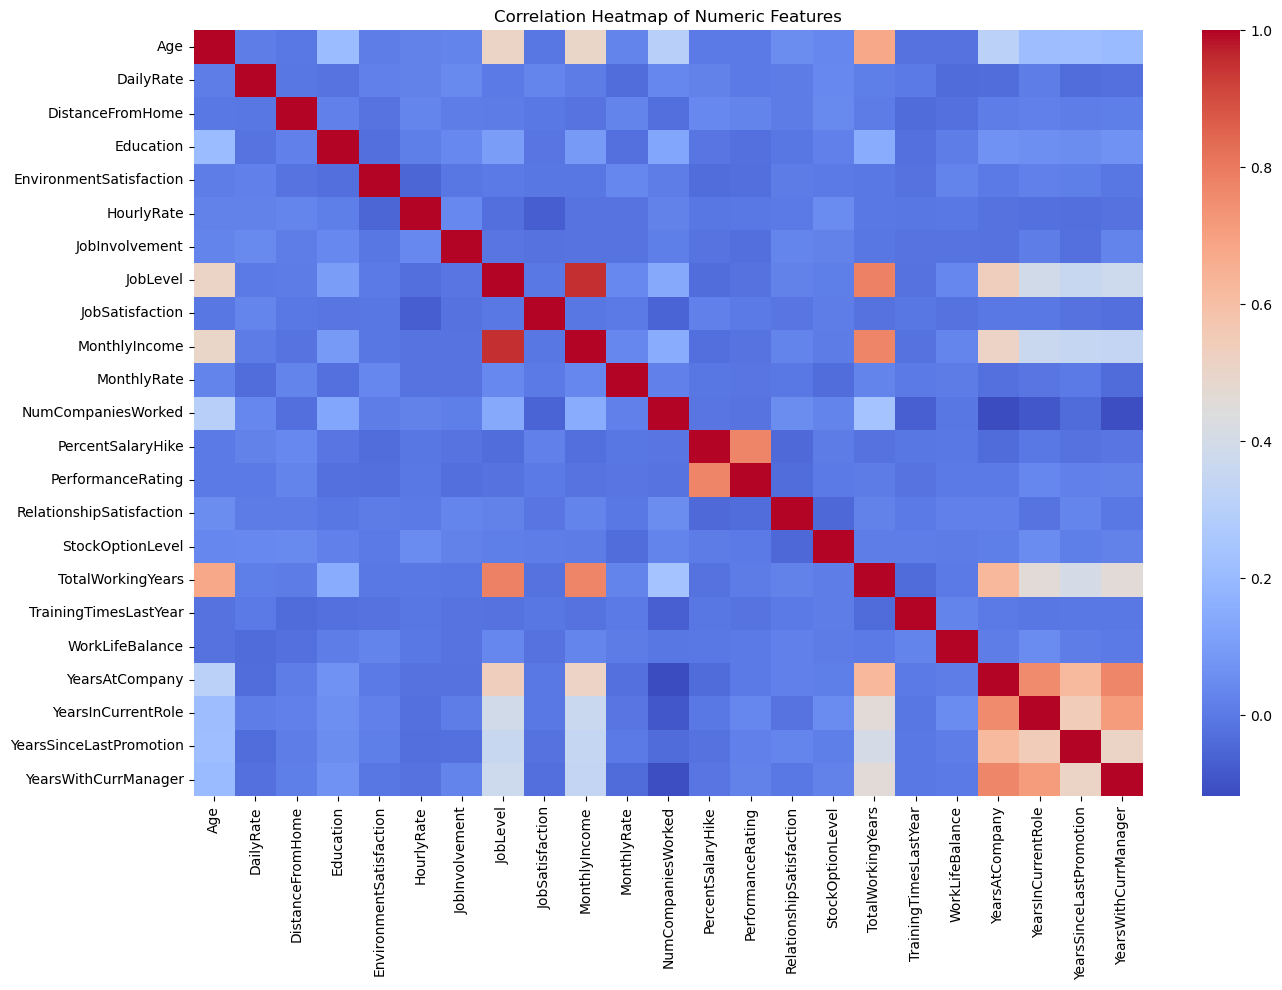

In [13]:
numeric_df = df.select_dtypes(include=[np.number]).copy()

plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

In [14]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("\nShape after encoding:", df_encoded.shape)
df_encoded.head()

Categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Shape after encoding: (1470, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


In [15]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " | Attrition cases:", y_train.sum())
print("Test shape:", X_test.shape, " | Attrition cases:", y_test.sum())

Train shape: (1176, 44)  | Attrition cases: 190
Test shape: (294, 44)  | Attrition cases: 47


In [23]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("=== Logistic Regression ===")
print(classification_report(y_test, log_preds, target_names=['Stayed', 'Left']))
print("ROC-AUC Score:", round(roc_auc_score(y_test, log_probs), 4))

print("\n=== Random Forest ===")
print(classification_report(y_test, rf_preds, target_names=['Stayed', 'Left']))
print("ROC-AUC Score:", round(roc_auc_score(y_test, rf_probs), 4))

=== Logistic Regression ===
              precision    recall  f1-score   support

      Stayed       0.91      0.77      0.84       247
        Left       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294

ROC-AUC Score: 0.7985

=== Random Forest ===
              precision    recall  f1-score   support

      Stayed       0.85      0.98      0.91       247
        Left       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294

ROC-AUC Score: 0.7707


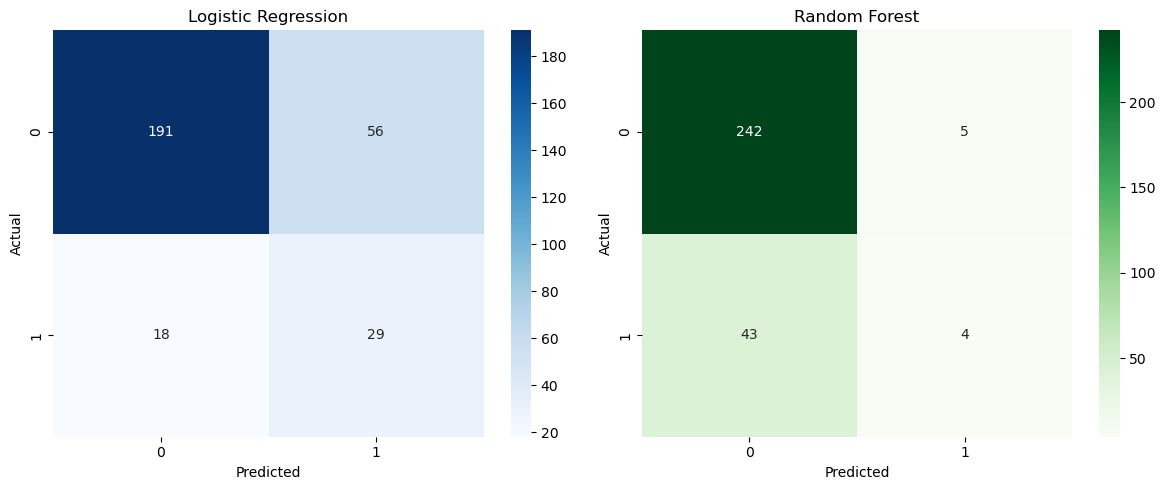

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(confusion_matrix(y_test, log_preds), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

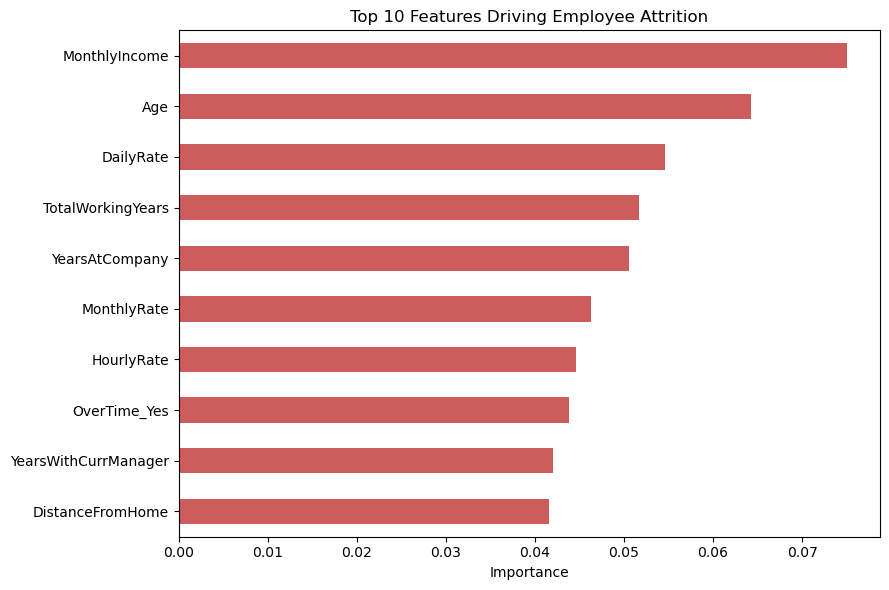

In [25]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(9,6))
importances.plot(kind='barh', color='indianred')
plt.title('Top 10 Features Driving Employee Attrition')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [26]:
df.to_csv('cleaned_hr_attrition.csv', index=False)
print("Cleaned dataset saved as 'cleaned_hr_attrition.csv'")

Cleaned dataset saved as 'cleaned_hr_attrition.csv'
